# Ground-Truth-Evaluation: Modell vs. manuelle Bewertung

Reproduzierbarer Vergleich der Prototyp-Scores gegen eine manuell bewertete Referenzstichprobe.
Logik in `src/evaluation/ground_truth.py`, Konzept in `docs/methodik_evaluation_ground_truth`.

**Ablauf:**
1. Modell auf der Stichprobe scoren (Testergebnisse).
2. Gefülltes Bewertungs-Template (`ground_truth_template*.csv`, 0–5 je Dimension) laden.
3. Mergen, Modell-Urteil per gleicher Regel ableiten (auf ganzzahliger GT-Skala).
4. Kennzahlen — Primärmetrik: Spearman ρ (gesamt + je Dimension, mit Ceiling-Analyse);
   Sekundär: Urteils-Übereinstimmung (Accuracy, gewichtetes κ mit Bootstrap-CI, PABAK,
   AUC, Konfusion); dazu MAE/RMSE/Bias.
5. Thesis-Grafiken erzeugen.

> **Vor dem Lauf:** die 0–5-Spalten (`gt_findability`, `gt_accessibility`, `gt_reusability`, `gt_expressiveness`) im Template ausfüllen — **blind** gegenüber den Modell-Scores.

In [1]:
from datetime import datetime
import sys
from pathlib import Path

# Repo-Root robust finden (egal von wo das Notebook startet).
REPO = Path.cwd()
while not (REPO / 'src').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

from dotenv import load_dotenv
load_dotenv(REPO / '.env')

import pandas as pd
from IPython.display import Image, display
from evaluation import ground_truth as gt
import importlib; importlib.reload(gt)  # immer frische Version laden

# ===================== Parameter =====================
SAMPLE_DIR   = REPO / 'data' / 'sample_2026-06-25_09-57'   # <- Stichproben-Verzeichnis
GT_CSV       = SAMPLE_DIR / 'ground_truth_template_slim_v2.csv'    # gefülltes Bewertungs-Template
# FIG_DIR      = SAMPLE_DIR / 'eval_figures'
FIG_DIR      = REPO / 'ground_truth_outputs' / (datetime.now().strftime('%Y-%m-%d_%H-%M-%S') + '_figures')
USE_LLM      = False   # expressiveness braucht das LLM (kostet Tokens!)
RECOMPUTE    = False   # True erzwingt Neuberechnung statt Cache

# Optional: bereits gelaufenen Run wiederverwenden statt neu zu scoren.
# Pfad zu einem Run-Verzeichnis (run_<timestamp>_.../) oder dessen
# run_aggregate.json. Wenn gesetzt, hat er Vorrang vor Cache/Neuberechnung —
# USE_LLM, RECOMPUTE und PROTO_CONFIG sind dann wirkungslos (die Scores kommen
# mitsamt ihrer damaligen Konfiguration aus dem Run).
# Beispiel:
#   RUN_PATH = REPO / 'run_outputs' / 'run_2026-07-01_10-00-00_state-default_sample'
RUN_PATH     = REPO / 'run_outputs' / 'run_2026-07-12_11-30-12_state-evaluation-final_EVAL'

# Prototyp-Konfiguration: Pfad zu einer State-YAML (conf/state/*.yaml) oder None für Defaults
# Beispiele:
#   PROTO_CONFIG = REPO / 'conf/state/state_weighted_tuning.yaml'
#   PROTO_CONFIG = REPO / 'conf/state/state_presentation_tuned.yaml'
PROTO_CONFIG = REPO / 'conf/state/state_evaluation_final.yaml'    # None = Standardkonfiguration (keine Gewichtung, alle Dimensionen)
# =====================================================
print('REPO     :', REPO)
print('SAMPLE   :', SAMPLE_DIR, '|', len(list(SAMPLE_DIR.glob('*.rdf'))), 'RDF-Dateien')
print('RUN_PATH :', RUN_PATH if RUN_PATH else '(nicht gesetzt — Modell wird gescort bzw. Cache genutzt)')

REPO     : /home/lbuerger/masterthesis/master_thesis_prototype
SAMPLE   : /home/lbuerger/masterthesis/master_thesis_prototype/data/sample_2026-06-25_09-57 | 50 RDF-Dateien
RUN_PATH : /home/lbuerger/masterthesis/master_thesis_prototype/run_outputs/run_2026-07-12_11-30-12_state-evaluation-final_EVAL


In [2]:
import yaml
from scoring.score_policy import ScorePolicy


def _service_kwargs_from_config(config_path):
    """Liest eine State-YAML und gibt die passenden QualityMetricsService-Kwargs zurück.

    Ausgewertete Felder: quality.{max_workers, dimension_weights, indicator_weights,
    dimension_whitelist, indicator_blacklist, indicator_whitelist, scoring} und language.
    Nicht gesetzte / leere Felder werden nicht übergeben → Service verwendet seine Defaults.
    """
    if config_path is None:
        print("PROTO_CONFIG : (Standard – keine YAML angegeben)")
        return {}

    p = Path(config_path)
    if not p.exists():
        raise FileNotFoundError(f"Config-Datei nicht gefunden: {p}")

    with open(p) as f:
        state = yaml.safe_load(f)

    q = state.get('quality', {})
    scoring_cfg = q.get('scoring')
    score_policy = ScorePolicy.from_config(scoring_cfg)

    kwargs = {}
    if q.get('max_workers') is not None:
        kwargs['max_workers'] = int(q['max_workers'])
    if q.get('dimension_weights'):
        kwargs['dimension_weights'] = dict(q['dimension_weights'])
    if q.get('indicator_weights'):
        kwargs['indicator_weights'] = dict(q['indicator_weights'])
    if q.get('dimension_whitelist'):
        kwargs['dimension_whitelist'] = list(q['dimension_whitelist'])
    if q.get('indicator_blacklist'):
        kwargs['indicator_blacklist'] = list(q['indicator_blacklist'])
    if q.get('indicator_whitelist'):
        kwargs['indicator_whitelist'] = list(q['indicator_whitelist'])
    if state.get('language'):
        kwargs['language'] = state['language']
    if score_policy is not None:
        kwargs['score_policy'] = score_policy

    print(f'PROTO_CONFIG : {p.name}')
    print(f'  dimension_whitelist : {kwargs.get("dimension_whitelist", "(alle)")}')
    print(f'  dimension_weights   : {kwargs.get("dimension_weights", "(Standard)")}')
    n_iw = len(kwargs['indicator_weights']) if 'indicator_weights' in kwargs else None
    print(f'  indicator_weights   : {"gesetzt (" + str(n_iw) + " Einträge)" if n_iw else "(Standard)"}')
    print(f'  score_policy        : {score_policy if score_policy else "(Standard)"}')
    return kwargs


SERVICE_KWARGS = _service_kwargs_from_config(PROTO_CONFIG)

PROTO_CONFIG : state_evaluation_final.yaml
  dimension_whitelist : ['accessibility', 'reusability', 'findability', 'expressiveness']
  dimension_weights   : {'accessibility': 2, 'reusability': 1.5, 'expressiveness': 2.0, 'findability': 1}
  indicator_weights   : gesetzt (25 Einträge)
  score_policy        : ScorePolicy(pass_score=1.0, partial_score=0.5, fail_score=0.0, allow_partial=True, overrides={})


## 1. Modell-Scores berechnen (mit Cache) — oder aus einem Run laden

**Drei Quellen, in dieser Vorrang-Reihenfolge:**
1. **`RUN_PATH` gesetzt** → Scores werden aus dem bereits gelaufenen Run gelesen
   (per-File `result.json`, Fallback `run_aggregate.json`). Kein Scoring, keine
   LLM-Kosten; `USE_LLM`/`RECOMPUTE`/`PROTO_CONFIG` sind wirkungslos.
   Die GT-CSV muss zur Stichprobe des Runs passen (Join über `file`).
2. **Cache vorhanden** (`model_scores_<config>.csv`) und `RECOMPUTE=False` → Cache laden.
3. **Sonst** → live scoren; bei `USE_LLM=True` mit LLM-Call je Datensatz (kostet Tokens!)
   und Ergebnis in den Cache schreiben.

In [3]:
if RUN_PATH is not None:
    # Bereits gelaufener Run: Scores 1:1 übernehmen (keine Neuberechnung).
    model_df = gt.load_model_scores(RUN_PATH)
else:
    _config_stem = Path(PROTO_CONFIG).stem if PROTO_CONFIG else 'default'
    scores_csv = SAMPLE_DIR / f'model_scores_{_config_stem}.csv'
    if scores_csv.exists() and not RECOMPUTE:
        model_df = pd.read_csv(scores_csv)
        print(f'Cache geladen: {scores_csv.name}')
    else:
        llm = gt.make_llm() if USE_LLM else None
        print('LLM:', 'an' if llm else 'aus (expressiveness = NaN)')
        model_df = gt.run_model_scores(SAMPLE_DIR, llm=llm, **SERVICE_KWARGS)
        model_df.to_csv(scores_csv, index=False)
        print('gespeichert:', scores_csv)
model_df.round(3)

loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/run_outputs/run_2026-07-12_11-30-12_state-evaluation-final_EVAL


,file,model_findability,model_accessibility,model_reusability,model_expressiveness,model_overall
0,geo_gdi-de.rdf,0.625,0.895,0.714,0.967,0.800
1,geo_gdi-de_02.rdf,0.625,0.605,0.714,0.750,0.674
2,geo_gdi-de_03.rdf,0.562,0.605,0.714,0.825,0.677
3,geo_gdi-de_04.rdf,0.625,0.605,0.714,0.842,0.697
4,geo_gdi-de_05.rdf,0.750,0.395,0.714,0.750,0.652
5,geo_open-data-brandenburg.rdf,0.625,0.798,0.714,0.717,0.714
6,geo_open-data-brandenburg_02.rdf,0.625,0.754,0.714,0.667,0.690
7,geo_open-data-brandenburg_03.rdf,0.625,0.798,0.714,0.733,0.718
8,geo_open-data-brandenburg_04.rdf,0.625,0.754,0.714,0.550,0.661
9,geo_open-data-brandenburg_05.rdf,0.625,0.798,0.714,NaN,0.713


## 2. Ground Truth laden

Leitet `gt_overall` (0–3-Mittel) und `gt_verdict` (gut/mittel/schlecht) aus den manuellen Bewertungen ab.

In [4]:
gt_df = gt.load_ground_truth(GT_CSV)
n_rated = int(gt_df['gt_rated'].sum())
print(f'Vollständig bewertet: {n_rated}/{len(gt_df)} Datensätze')
gt_df[['file'] + gt.GT_COLS + ['gt_overall', 'gt_verdict']].head(10)

Vollständig bewertet: 50/50 Datensätze


,file,gt_findability,gt_accessibility,gt_reusability,gt_expressiveness,gt_overall,gt_verdict
0,geo_gdi-de.rdf,3,0,3,4,2.50,mittel
1,geo_gdi-de_02.rdf,4,3,4,4,3.75,mittel
2,geo_gdi-de_03.rdf,3,3,4,4,3.50,mittel
3,geo_gdi-de_04.rdf,3,3,4,4,3.50,mittel
4,geo_gdi-de_05.rdf,4,3,4,3,3.50,mittel
5,geo_open-data-brandenburg.rdf,4,3,5,4,4.00,gut
6,geo_open-data-brandenburg_02.rdf,4,3,4,4,3.75,mittel
7,geo_open-data-brandenburg_03.rdf,4,3,4,4,3.75,mittel
8,geo_open-data-brandenburg_04.rdf,4,3,4,4,3.75,mittel
9,geo_open-data-brandenburg_05.rdf,4,3,4,4,3.75,mittel


## 3. Merge & Vergleich

Modell-Dimensionsscores werden auf 0–5 reskaliert (×5). Für das Modell-**Urteil** werden sie
zusätzlich auf die ganzzahlige GT-Skala gerundet, bevor **dieselbe** Urteilsregel angewendet wird:
die Schwellen der Regel (z. B. „keine Dimension unter 3") sind auf ganzzahlige Bewertungen
kalibriert — ein kontinuierliches 2.86 drückt dasselbe Urteil aus wie eine manuelle 3, würde die
konjunktive Klausel aber kategorisch reißen (Diskretisierungs-Asymmetrie). Die Korrelations- und
Fehlermetriken nutzen weiterhin die ungerundeten Werte.

In [5]:
merged = gt.merge_scores(gt_df, model_df)

if merged['gt_verdict'].notna().sum() == 0:
    print('Noch keine Bewertungen vorhanden — bitte die 0–5-Spalten im Template füllen und neu laufen lassen.')
    result = None
else:
    result = gt.compare(merged)
    o = result['overall']

    print('=== Pro Dimension (Rangkorrelation Modell ↔ GT) ===')
    display(gt.summary_table(result))

    print('\n=== Gesamt-Rangkorrelation (kontinuierlich, 0–5-Skala) ← Primärmetrik ===')
    print(f'  Spearman ρ gesamt : {o["spearman_overall"]:.3f}')
    print(f'  Kendall τ gesamt  : {o["kendall_overall"]:.3f}')
    print(f'  Ø Spearman Dimens.: {o["mean_spearman_dims"]:.3f}')

    print('\n=== Fehlergröße (0–5-Skala) ===')
    print(f'  MAE               : {o["mae"]:.3f}  Skalenpunkte Ø Abweichung')
    print(f'  RMSE              : {o["rmse"]:.3f}')
    bias_dir = 'überschätzt' if o['bias'] > 0 else 'unterschätzt'
    print(f'  Bias              : {o["bias"]:+.3f}  (Modell {bias_dir} systematisch)')

    print('\n=== Gesamturteil (Klassifikation, Sekundärmetrik) ===')
    n_total = len(merged)
    ci_lo, ci_hi = o['weighted_kappa_ci']
    print(f'  n gesamt          : {n_total}')
    print(f'  n bewertet        : {o["n_graded"]}')
    print(f'  Accuracy          : {o["accuracy"]:.3f}')
    print(f'  Cohen κ (gewichtet): {o["weighted_kappa"]:.3f}   [Bootstrap-95%-CI: {ci_lo:.3f}, {ci_hi:.3f}]')
    print(f'  PABAK             : {o["pabak"]:.3f}   (prävalenzbereinigt, Byrt et al. 1993)')
    print(f'  Cohen κ (ungewicht): {o["cohen_kappa"]:.3f}')
    print(f'  AUC gut vs. rest  : {o["auc_gut_vs_rest"]:.3f}   (schwellenfrei)')
    print('  Hinweis: GT-Urteile sind stark auf "mittel" konzentriert (reale Stichprobe) —')
    print('  κ ist dadurch strukturell gedeckelt und instabil (Kappa-Paradox, breites CI);')
    print('  deshalb Sekundärmetrik. Modell-Urteil auf ganzzahliger GT-Skala abgeleitet.')

    print('\n=== Konfusionsmatrix (Zeilen=GT, Spalten=Modell) ===')
    display(result['confusion'])

=== Pro Dimension (Rangkorrelation Modell ↔ GT) ===


,spearman,kendall_tau,n
findability,0.524,0.469,50.0
accessibility,0.682,0.571,50.0
reusability,0.739,0.694,50.0
expressiveness,0.649,0.538,28.0



=== Gesamt-Rangkorrelation (kontinuierlich, 0–5-Skala) ← Primärmetrik ===
  Spearman ρ gesamt : 0.763
  Kendall τ gesamt  : 0.646
  Ø Spearman Dimens.: 0.649

=== Fehlergröße (0–5-Skala) ===
  MAE               : 0.273  Skalenpunkte Ø Abweichung
  RMSE              : 0.361
  Bias              : -0.009  (Modell unterschätzt systematisch)

=== Gesamturteil (Klassifikation, Sekundärmetrik) ===
  n gesamt          : 50
  n bewertet        : 28
  Accuracy          : 0.929
  Cohen κ (gewichtet): -0.037   [Bootstrap-95%-CI: -0.094, 0.000]
  PABAK             : 0.893   (prävalenzbereinigt, Byrt et al. 1993)
  Cohen κ (ungewicht): -0.037
  AUC gut vs. rest  : 0.852   (schwellenfrei)
  Hinweis: GT-Urteile sind stark auf "mittel" konzentriert (reale Stichprobe) —
  κ ist dadurch strukturell gedeckelt und instabil (Kappa-Paradox, breites CI);
  deshalb Sekundärmetrik. Modell-Urteil auf ganzzahliger GT-Skala abgeleitet.

=== Konfusionsmatrix (Zeilen=GT, Spalten=Modell) ===


,M:schlecht,M:mittel,M:gut
GT:schlecht,0,0,0
GT:mittel,0,26,1
GT:gut,0,1,0


## 3b. Größte Abweichungen: Datei × Dimension

Zeigt pro Dimension und gesamt, wo Modell und manuelles Urteil am stärksten auseinanderlaufen.
Nützlich für die qualitative Diskussion in der Thesis (§6 `docs/evaluation_vs_mqa.md`).

In [6]:
if result is not None:
    import pandas as pd
    from evaluation.ground_truth import DIM_MAP

    TOP_N = 20  # Anzahl der auffälligsten Fälle je Dimension

    # ── Pro Dimension: Top-Abweichungen ─────────────────────────────────────
    print('=== Größte Abweichungen pro Dimension (|Modell_0-5 − GT| absteigend) ===')
    diff_frames = []
    for gt_col, dim in DIM_MAP.items():
        model_col = f'model_{dim}_0_5'
        sub = merged[['file', gt_col, model_col]].dropna().copy()
        sub['diff'] = sub[model_col] - sub[gt_col]
        sub['abs_diff'] = sub['diff'].abs()
        sub['dimension'] = dim
        sub = sub.rename(columns={gt_col: 'gt', model_col: 'modell'})
        diff_frames.append(sub)

        top = sub.nlargest(TOP_N, 'abs_diff')[['file', 'gt', 'modell', 'diff']]
        print(f'\n  {dim}')
        for _, row in top.iterrows():
            direction = '↑ Modell zu hoch' if row['diff'] > 0 else '↓ Modell zu niedrig'
            print(f'    {row["file"]:<45}  GT={row["gt"]:.1f}  M={row["modell"]:.1f}  Δ={row["diff"]:+.2f}  {direction}')

    # ── Gesamt: Top-Abweichungen über alle Dimensionen ──────────────────────
    all_diffs = pd.concat(diff_frames, ignore_index=True)
    print(f'\n=== Gesamt-Top-{TOP_N*2}: größte Einzelabweichungen über alle Dimensionen ===')
    top_all = all_diffs.nlargest(TOP_N * 2, 'abs_diff')[['file', 'dimension', 'gt', 'modell', 'diff']]
    display(top_all.assign(
        diff=top_all['diff'].map('{:+.2f}'.format),
        gt=top_all['gt'].round(1),
        modell=top_all['modell'].round(2),
    ).reset_index(drop=True))

    # ── Datensätze mit konsistent hoher Abweichung (Mittel über Dimensionen) 
    file_mean_diff = (
        all_diffs.groupby('file')['abs_diff']
        .mean()
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    print(f'\n=== Top-{TOP_N} Datensätze mit höchster Ø-Abweichung über alle Dimensionen ===')
    for fname, mean_diff in file_mean_diff.items():
        row = merged[merged['file'] == fname].iloc[0]
        verdict_gt  = row.get('gt_verdict', '?')
        verdict_mod = row.get('model_verdict', '?')
        print(f'  {fname:<45}  Ø|Δ|={mean_diff:.2f}  GT={verdict_gt}  Modell={verdict_mod}')
else:
    print('Übersprungen — keine Bewertungen.')

=== Größte Abweichungen pro Dimension (|Modell_0-5 − GT| absteigend) ===

  findability
    non_geo_land-schleswig-holstein_03.rdf         GT=3.0  M=4.4  Δ=+1.38  ↑ Modell zu hoch
    geo_open-data-portal-rheinland-pfalz_05.rdf    GT=2.0  M=3.1  Δ=+1.12  ↑ Modell zu hoch
    non_geo_rest.rdf                               GT=3.0  M=1.9  Δ=-1.12  ↓ Modell zu niedrig
    geo_gdi-de_02.rdf                              GT=4.0  M=3.1  Δ=-0.88  ↓ Modell zu niedrig
    geo_open-data-brandenburg.rdf                  GT=4.0  M=3.1  Δ=-0.88  ↓ Modell zu niedrig
    geo_open-data-brandenburg_02.rdf               GT=4.0  M=3.1  Δ=-0.88  ↓ Modell zu niedrig
    geo_open-data-brandenburg_03.rdf               GT=4.0  M=3.1  Δ=-0.88  ↓ Modell zu niedrig
    geo_open-data-brandenburg_04.rdf               GT=4.0  M=3.1  Δ=-0.88  ↓ Modell zu niedrig
    geo_open-data-brandenburg_05.rdf               GT=4.0  M=3.1  Δ=-0.88  ↓ Modell zu niedrig
    geo_rest_02.rdf                                GT=1.0  M=1.

,file,dimension,gt,modell,diff
0,geo_gdi-de.rdf,accessibility,0,4.47,+4.47
1,non_geo_open-data-bayern_03.rdf,accessibility,1,3.06,+2.06
2,non_geo_open-data-bayern_05.rdf,accessibility,1,3.06,+2.06
3,geo_open-data-portal-rheinland-pfalz_02.rdf,accessibility,1,2.68,+1.68
4,geo_open-data-brandenburg.rdf,reusability,5,3.57,-1.43
5,non_geo_gdi-de.rdf,reusability,5,3.57,-1.43
6,non_geo_open-data-brandenburg_05.rdf,accessibility,2,3.42,+1.42
7,non_geo_gdi-de_04.rdf,expressiveness,4,2.58,-1.42
8,non_geo_land-schleswig-holstein_03.rdf,findability,3,4.38,+1.38
9,geo_open-data-brandenburg_04.rdf,expressiveness,4,2.75,-1.25



=== Top-20 Datensätze mit höchster Ø-Abweichung über alle Dimensionen ===
  geo_gdi-de.rdf                                 Ø|Δ|=1.50  GT=mittel  Modell=gut
  non_geo_land-schleswig-holstein_03.rdf         Ø|Δ|=1.17  GT=mittel  Modell=nan
  non_geo_gdi-de.rdf                             Ø|Δ|=0.94  GT=mittel  Modell=mittel
  geo_open-data-brandenburg.rdf                  Ø|Δ|=0.93  GT=gut  Modell=mittel
  non_geo_open-data-bayern_05.rdf                Ø|Δ|=0.89  GT=mittel  Modell=nan
  geo_open-data-portal-rheinland-pfalz_05.rdf    Ø|Δ|=0.85  GT=mittel  Modell=mittel
  non_geo_rest_04.rdf                            Ø|Δ|=0.85  GT=mittel  Modell=nan
  geo_open-data-brandenburg_04.rdf               Ø|Δ|=0.83  GT=mittel  Modell=mittel
  non_geo_open-data-bayern_03.rdf                Ø|Δ|=0.80  GT=mittel  Modell=nan
  non_geo_land-schleswig-holstein_05.rdf         Ø|Δ|=0.79  GT=mittel  Modell=nan
  non_geo_open-data-brandenburg_05.rdf           Ø|Δ|=0.78  GT=mittel  Modell=nan
  geo_open-dat

## 3c. Attenuation-Analyse: Wie viel Korrelation ist überhaupt erreichbar?

Die Dimensions-Korrelationen wirken verstreut, obwohl die Gesamt-Korrelation hoch ist.
Zwei bekannte messtheoretische Effekte erklären das:

1. **Ceiling-ρ je Dimension** (Hauptargument, annahmearm) — die GT-Skala ist grob
   (0–5 ganzzahlig, faktisch werden oft nur 2–3 Stufen genutzt) und die Stichprobe
   enthält Portal-Duplikate (Ties). Selbst ein *perfekt* monotones Modell erreicht
   damit kein ρ = 1. Das Ceiling ist das maximal erreichbare Spearman-ρ bei gegebener
   GT-Werteverteilung; der Quotient `beobachtet / Ceiling` zeigt, wie nah das Modell
   am Erreichbaren liegt. Einzige Annahme: Monotonie.
2. **Disattenuation des Gesamtscores** (Zusatzindiz, mit Vorsicht) — klassische
   Korrektur nach Spearman: `r_latent = r / √(rel_GT · rel_Modell)` mit Cronbachs α
   der Dimensionswerte als Reliabilitätsschätzer. **Caveat:** die vier Dimensionen
   messen absichtlich *verschiedene* Konstrukte, daher unterschätzt α die Reliabilität
   deutlich und die Korrektur überschießt (wird bei 1.0 gekappt). In der Thesis als
   grobe Obergrenzen-Abschätzung kennzeichnen, nicht als Punktschätzer — das
   tragfähige Argument ist die Ceiling-Analyse.

Kendall τ-b (behandelt Ties fairer als Spearman) steht als Vergleich daneben.
Interpretation für die Thesis: §Limitations — niedrige Dimensions-ρ sind zu großen
Teilen Skalen-/Stichprobenartefakte, kein Modellversagen.

In [7]:
if result is not None:
    import numpy as np
    from evaluation.ground_truth import (
        DIM_MAP, MODEL_DIMS, GT_COLS,
        ceiling_spearman, cronbach_alpha, disattenuated_correlation,
    )

    # ── 1) Ceiling-Analyse pro Dimension ────────────────────────────────────
    rows = []
    for gt_col, dim in DIM_MAP.items():
        x, y = merged[f'model_{dim}'], merged[gt_col]
        obs = result['per_dimension'].loc[dim, 'spearman']
        tau = result['per_dimension'].loc[dim, 'kendall_tau']
        ceil = ceiling_spearman(x, y)
        rows.append({
            'dimension': dim,
            'spearman_beobachtet': obs,
            'spearman_ceiling': ceil,
            'anteil_vom_ceiling': obs / ceil if ceil and not np.isnan(ceil) else np.nan,
            'kendall_tau_b': tau,
            'gt_stufen_genutzt': int(merged[gt_col].nunique()),
        })
    ceiling_df = pd.DataFrame(rows).set_index('dimension')
    print('=== Ceiling-Analyse: beobachtetes ρ vs. maximal erreichbares ρ ===')
    display(ceiling_df.round(3))

    # ── 2) Disattenuation des Gesamtscores ──────────────────────────────────
    alpha_gt    = cronbach_alpha(merged[GT_COLS])
    alpha_model = cronbach_alpha(merged[[f'model_{d}' for d in MODEL_DIMS]])
    r_obs  = result['overall']['spearman_overall']
    r_true = disattenuated_correlation(r_obs, alpha_gt, alpha_model)

    print('\n=== Disattenuation (Gesamtscore) ===')
    print(f'  Cronbachs α GT-Dimensionen     : {alpha_gt:.3f}')
    print(f'  Cronbachs α Modell-Dimensionen : {alpha_model:.3f}')
    print(f'  Spearman ρ beobachtet          : {r_obs:.3f}')
    print(f'  Spearman ρ disattenuiert       : {r_true:.3f}   (geschätzte latente Übereinstimmung)')
    if not np.isnan(r_true):
        print(f'  Dämpfung durch Messunreliabilität: {r_true - r_obs:+.3f}')
else:
    print('Übersprungen — keine Bewertungen.')

=== Ceiling-Analyse: beobachtetes ρ vs. maximal erreichbares ρ ===


,spearman_beobachtet,spearman_ceiling,anteil_vom_ceiling,kendall_tau_b,gt_stufen_genutzt
dimension,,,,,
findability,0.524,0.768,0.683,0.469,4
accessibility,0.682,0.952,0.716,0.571,6
reusability,0.739,0.928,0.796,0.694,6
expressiveness,0.649,0.851,0.762,0.538,4



=== Disattenuation (Gesamtscore) ===
  Cronbachs α GT-Dimensionen     : 0.563
  Cronbachs α Modell-Dimensionen : -0.001
  Spearman ρ beobachtet          : 0.763
  Spearman ρ disattenuiert       : nan   (geschätzte latente Übereinstimmung)


## 4. Grafiken (thesis-tauglich)

Werden als PNG in `eval_figures/` gespeichert und hier angezeigt.

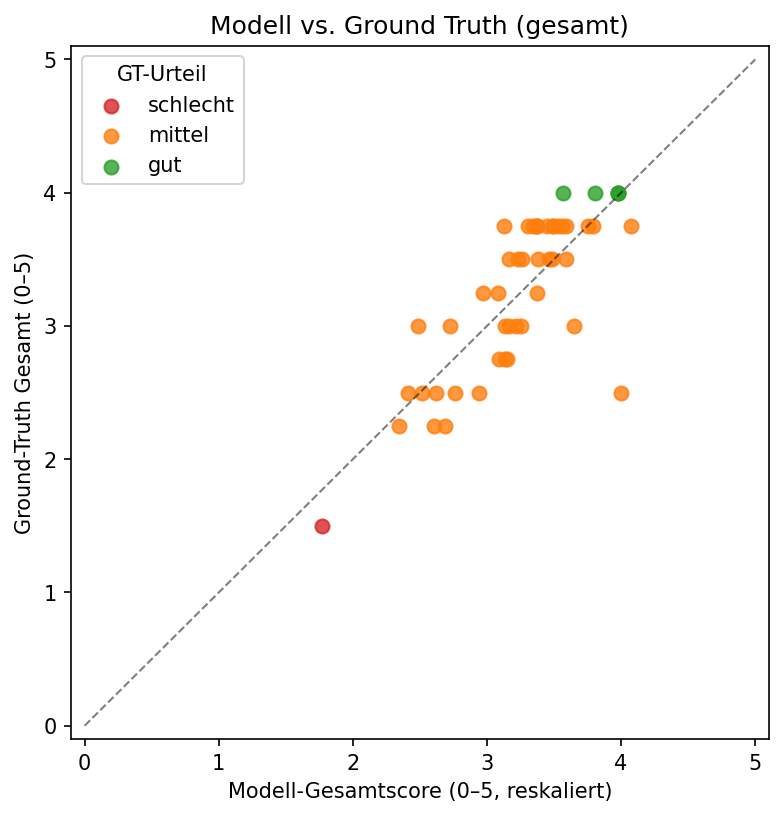

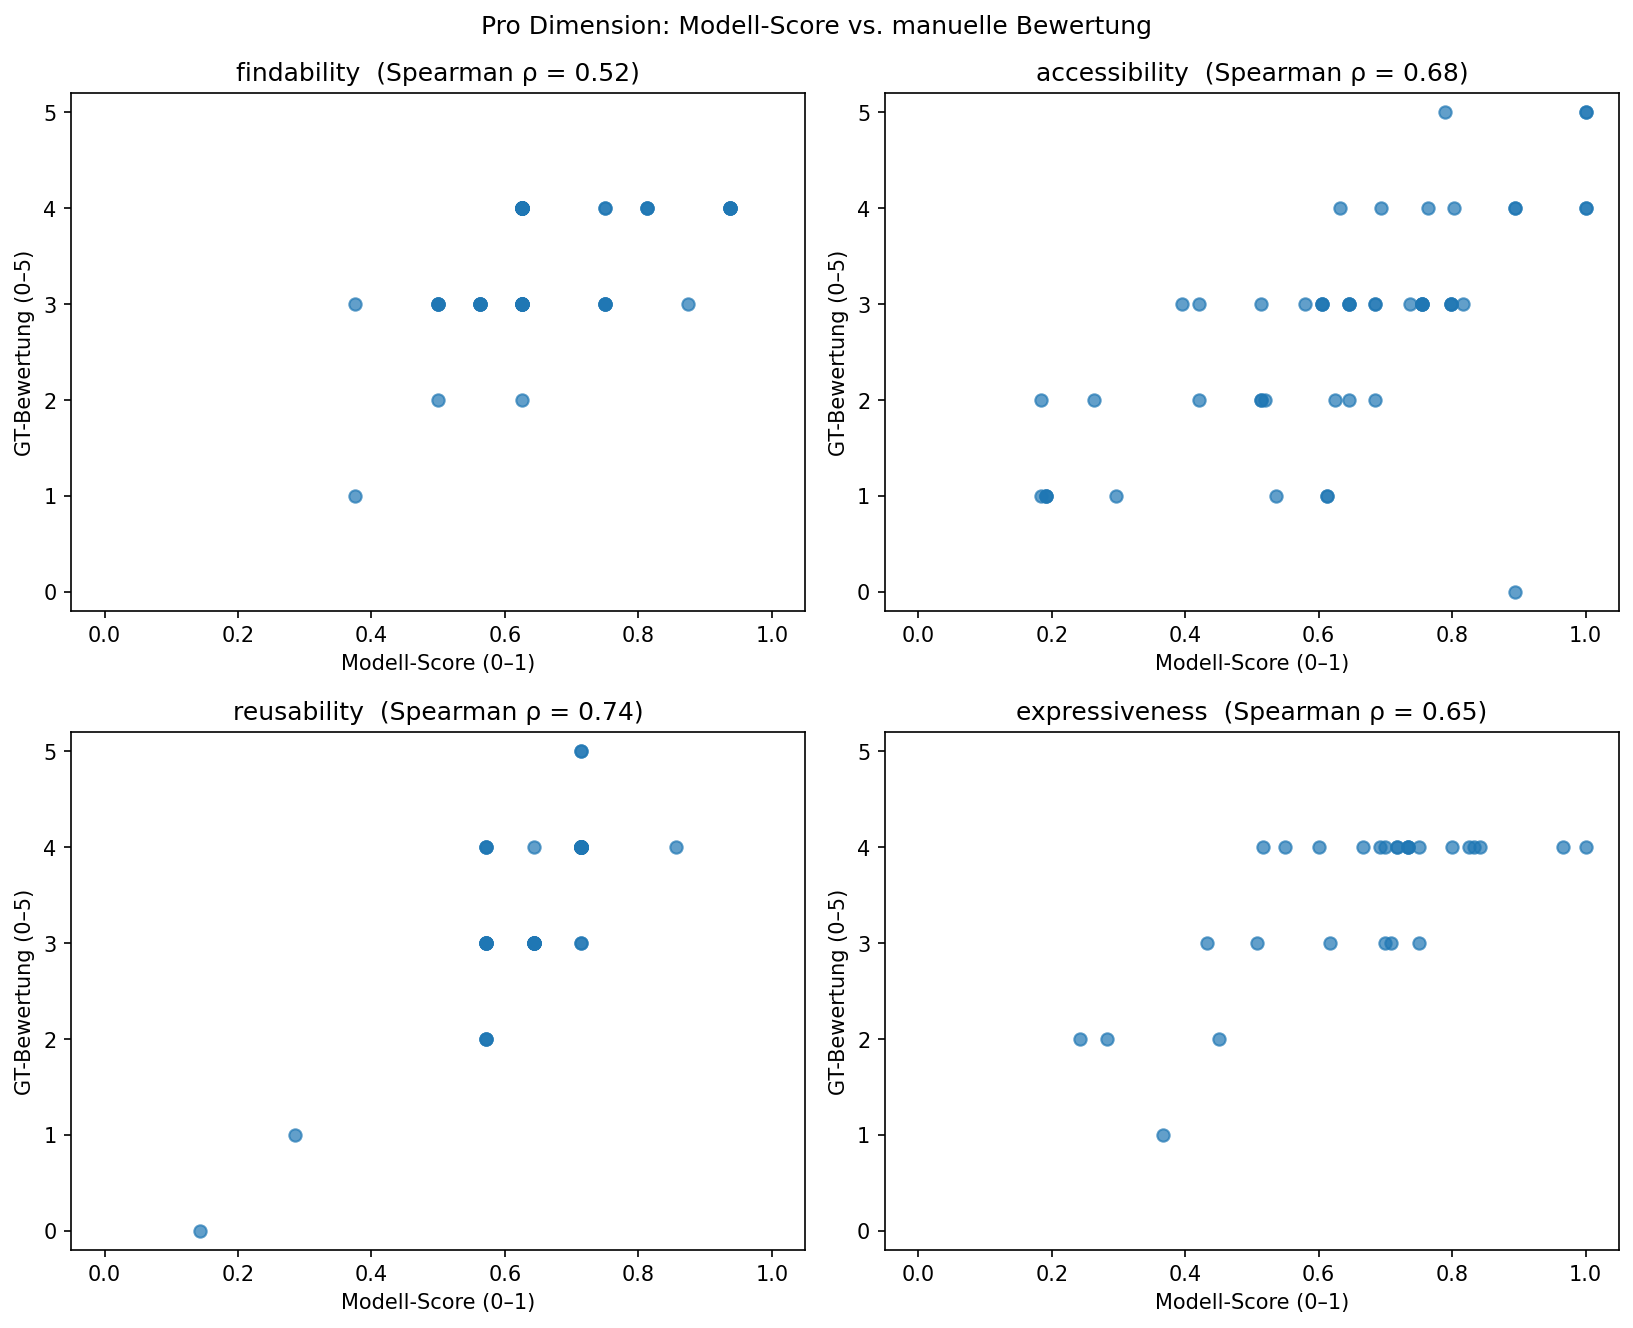

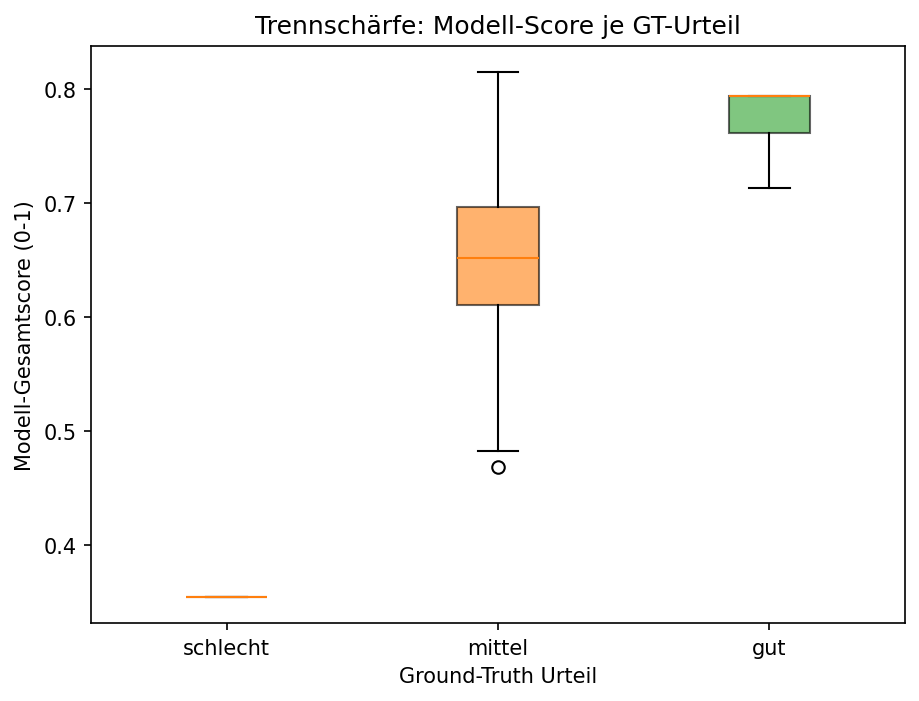

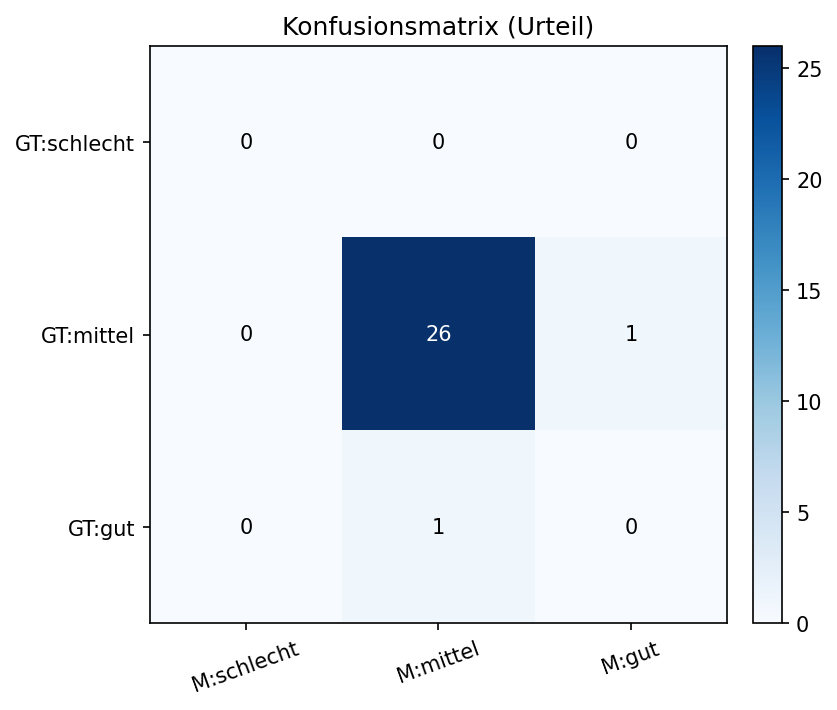

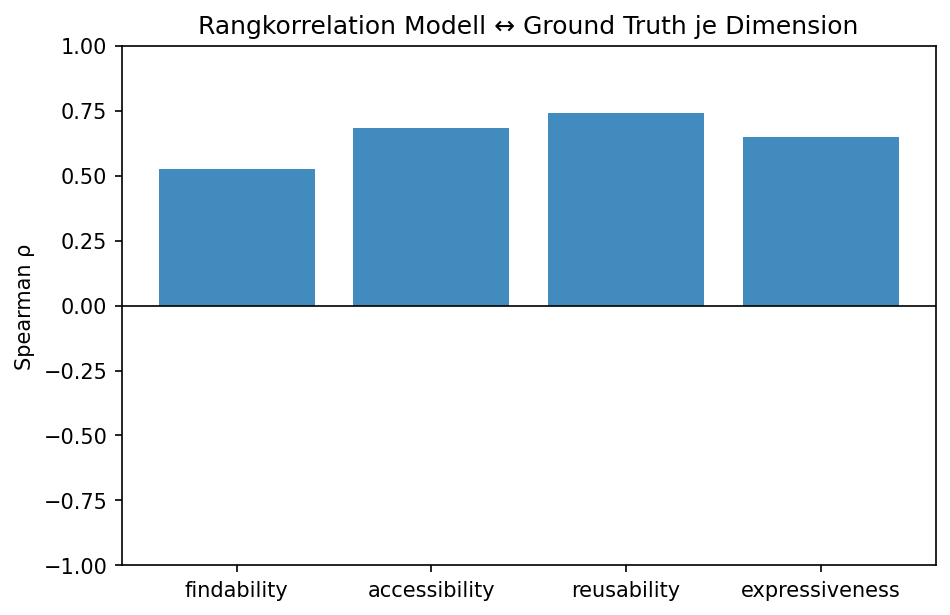

gespeichert:
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-12_13-14-39_figures/overall_scatter.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-12_13-14-39_figures/per_dimension_scatter.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-12_13-14-39_figures/separation_boxplot.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-12_13-14-39_figures/confusion_matrix.png
   /home/lbuerger/masterthesis/master_thesis_prototype/ground_truth_outputs/2026-07-12_13-14-39_figures/spearman_per_dimension.png


In [8]:
if result is not None:
    paths = gt.make_figures(merged, result, FIG_DIR)
    for p in paths:
        display(Image(str(p)))
    print('gespeichert:')
    for p in paths:
        print('  ', p)
else:
    print('Übersprungen — keine Bewertungen.')

## 5. Getrennt: Kernstichprobe vs. Extremfälle

Laut Methodik werden Kernstichprobe und Extremfälle **getrennt** ausgewertet. Dazu dieses Notebook ein zweites Mal mit `SAMPLE_DIR = REPO/'data'/'extreme_cases'` (bzw. dem Extremfall-Verzeichnis) laufen lassen — dort ebenfalls vorher ein `ground_truth_template.csv` via `scripts/build_ground_truth_template.py <dir>` erzeugen und bewerten.

Optional lassen sich beide Ergebnis-Tabellen am Ende nebeneinanderstellen (z. B. `pd.concat` der jeweiligen `summary_table`).